# Semantic Shard Prototype - Step 2 (Build Weighted Shard Graph)

This notebook builds a **new shard graph object** from Stage-1 semantic shards.

Scope of Step 2:
- node = semantic shard (campaign fragment)
- candidate edges from semantic and infrastructure evidence
- interpretable weighted edge score
- structural graph diagnostics and bridgeability checks

Out of scope in Step 2:
- GNN training on the shard graph
- final campaign grouping/community detection

**Routing-channel experiment:** In the controls cell, set `INCLUDE_ROUTING_CHANNELS_IN_GRAPH = True` to add `origin_ip`, `received_host`, `return_path_email`, and `return_path_domain` to shard sets (from the hetero graph), create extra infra candidate edges where those values overlap, and score them with the existing `SHARD_EDGE_SCORING_LOGICAL` `"routed"` blocks. Outputs go to `analysis/output/semantic_shard_step2_graph_routing/` so the default graph folder is unchanged. Then in Step 3 set `USE_STEP2_ROUTING_GRAPH = True` (and re-run Step 3; artifacts go to `semantic_shard_step3_routing/`).


## Fast run order

Inspect these first:
1. **Stage-1 artifact load + sanity check**
2. **Shard node feature construction**
3. **Candidate edge rules**
4. **Weighted edge formula + edge table**
5. **Graph structural diagnostics** (+ optional **5b layout plot**)
6. **Bridgeability of fragmented campaigns**
7. **Saved Step-2 artifacts**


In [1]:
from pathlib import Path
import sys
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_here = Path.cwd().resolve()
PROJECT_ROOT = _here if (_here / "pipeline_config.json").is_file() else _here.parent
assert (PROJECT_ROOT / "pipeline_config.json").is_file(), f"Set cwd to repo root or analysis/; got {PROJECT_ROOT}"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.utils import graph_structure_helpers as gh
from analysis.utils import raw_gnn_notebook as rn
from analysis.utils import semantic_shard_helpers as ssh
from analysis.utils import semantic_shard_graph_helpers as s2

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 200)


In [2]:
# -------- Controls --------
STEP1_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step1"
STEP1_ASSIGNMENTS_CSV = STEP1_DIR / "semantic_shard_step1_assignments.csv"
STEP1_SHARD_SUMMARY_CSV = STEP1_DIR / "semantic_shard_step1_shard_summary.csv"

EMBEDDINGS_JSON = PROJECT_ROOT / "core" / "utils" / "embeddings" / "output" / "embeddings.json"
GRAPH_PT = PROJECT_ROOT / "core" / "graph" / "output" / "incidents-lake-misp_hetero.pt"
GRAPH_META = GRAPH_PT.with_suffix(".meta.json")
GT_DEDUP_PATH = PROJECT_ROOT / "data" / "groundtruth" / "ground_truth.json"

# Candidate generation (semantic gating)
SEMANTIC_TOP_K = 8
# Semantic centroid cosine threshold used to accept semantic candidate shard edges.
SEMANTIC_MIN_COS = 0.95

# ---------- Graph design knobs (Step-2) ----------
# Logical infrastructure channels (not all may exist in this dataset).
# Logical names map to shard_nodes_df set columns like <channel>_set (from hetero email artifact sets).
#
# Routing-style channels (MTA / path): when included, they participate in **candidate** edges
# (shared values connect shards) and in **infra_score** / edge_weight via SHARD_EDGE_SCORING_LOGICAL.
INCLUDE_ROUTING_CHANNELS_IN_GRAPH = False  # set True to rebuild with origin_ip, received_host, return_path_*

BASE_INFRA_CHANNELS_LOGICAL = [
    "url",
    "sender_email_domain",
    "domain",
    "stem",
    "sender",
    # "attachment",  # optional: add here if you want attachment-based candidates/scoring
]

ROUTING_INFRA_CHANNELS_LOGICAL = (
    "origin_ip",
    "received_host",
    "return_path_email",
    "return_path_domain",
)

ENABLED_INFRA_CHANNELS_LOGICAL = list(BASE_INFRA_CHANNELS_LOGICAL)
if INCLUDE_ROUTING_CHANNELS_IN_GRAPH:
    ENABLED_INFRA_CHANNELS_LOGICAL = ENABLED_INFRA_CHANNELS_LOGICAL + list(ROUTING_INFRA_CHANNELS_LOGICAL)

# Which channels are allowed to create infra candidates.
# If None, this defaults to ENABLED_INFRA_CHANNELS_LOGICAL.
CANDIDATE_INFRA_CHANNELS_LOGICAL = None

# Which channels contribute to the final infra_score / edge_weight.
SCORING_INFRA_CHANNELS_LOGICAL = ENABLED_INFRA_CHANNELS_LOGICAL

# Per-channel shard-edge infra scoring (see also `s2.FREQUENCY_STAT_NOTE` and the Step-2 ledger).
# EASIEST TWEAKS for coarse routing: adjust the blocks for `origin_ip`, `received_host`, and (moderately) `return_path_*`.
#
# - enabled: False removes the channel from infra_score even if listed in SCORING_INFRA_CHANNELS_LOGICAL.
# - scoring_mode "legacy": weight * (1 - exp(-sum idf_raw)) on shared artifacts after max_shard_df filter (original core behavior).
# - scoring_mode "routed": per shared artifact add weight * (1 - exp(-effective_idf)), with
#     effective_idf = idf_scale * idf_raw ** idf_exponent, then apply contribution_cap for that channel.
# - max_shard_df: shared artifacts appearing in more than this many shards are ignored (None = no cutoff).
#
SHARD_EDGE_SCORING_LOGICAL = {
    "url": dict(
        enabled=True,
        weight=1.00,
        scoring_mode="legacy",
        idf_exponent=1.0,
        idf_scale=1.0,
        max_shard_df=None,
        contribution_cap=None,
    ),
    "sender_email_domain": dict(
        enabled=True,
        weight=0.85,
        scoring_mode="legacy",
        idf_exponent=1.0,
        idf_scale=1.0,
        max_shard_df=None,
        contribution_cap=None,
    ),
    "domain": dict(
        enabled=True,
        weight=0.60,
        scoring_mode="legacy",
        idf_exponent=1.0,
        idf_scale=1.0,
        max_shard_df=None,
        contribution_cap=None,
    ),
    "stem": dict(
        enabled=True,
        weight=0.55,
        scoring_mode="legacy",
        idf_exponent=1.0,
        idf_scale=1.0,
        max_shard_df=None,
        contribution_cap=None,
    ),
    "sender": dict(
        enabled=True,
        weight=0.50,
        scoring_mode="legacy",
        idf_exponent=1.0,
        idf_scale=1.0,
        max_shard_df=None,
        contribution_cap=None,
    ),
    "attachment": dict(
        enabled=True,
        weight=0.45,
        scoring_mode="legacy",
        idf_exponent=1.0,
        idf_scale=1.0,
        max_shard_df=None,
        contribution_cap=None,
    ),
    "origin_ip": dict(
        enabled=True,
        weight=0.16,
        scoring_mode="routed",
        idf_exponent=2.2,
        idf_scale=0.32,
        max_shard_df=100,
        contribution_cap=0.09,
    ),
    "received_host": dict(
        enabled=True,
        weight=0.14,
        scoring_mode="routed",
        idf_exponent=2.5,
        idf_scale=0.28,
        max_shard_df=80,
        contribution_cap=0.07,
    ),
    "return_path_email": dict(
        enabled=True,
        weight=0.22,
        scoring_mode="routed",
        idf_exponent=1.6,
        idf_scale=0.55,
        max_shard_df=150,
        contribution_cap=0.14,
    ),
    "return_path_domain": dict(
        enabled=True,
        weight=0.26,
        scoring_mode="routed",
        idf_exponent=1.5,
        idf_scale=0.60,
        max_shard_df=180,
        contribution_cap=0.16,
    ),
}

# Edge score mixture weights (semantic vs infra vs temporal).
SEMANTIC_WEIGHT = 0.45
INFRA_WEIGHT = 0.45
TEMPORAL_WEIGHT = 0.10

# Output artifacts (separate folder when routing channels are on, so baseline graph is preserved)
STEP2_OUT_DIR = (
    PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step2_graph_routing"
    if INCLUDE_ROUTING_CHANNELS_IN_GRAPH
    else PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step2_graph"
)


## 1) Load Stage-1 artifacts and confirm reuse

What this section checks:
- Step-1 shard assignments are present and usable
- number of shard nodes / email assignments
- shard_id mapping format
- any shard-level summary fields already available from Step 1


In [3]:
if not STEP1_ASSIGNMENTS_CSV.exists():
    print("Step-1 assignments not found. Bootstrapping Step-1 artifacts with default settings...")
    STEP1_DIR.mkdir(parents=True, exist_ok=True)

    # Step-1 defaults (kept aligned with step1 notebook defaults)
    _MIN_CLUSTER_SIZE = 2
    _MIN_SAMPLES = None
    _FALLBACK_COS_THRESHOLD = 0.22
    _NOISE_AS_SINGLETON = True

    _, _id_to_semantic_boot, _ = ssh.load_transformer_cache(EMBEDDINGS_JSON)
    _meta = gh.load_meta(GRAPH_META)
    _graph_external_ids = gh.email_external_id_list(_meta)
    _gt_label_map_boot, _, _ = rn.load_ground_truth_structures(GT_DEDUP_PATH)

    _aligned_ids = sorted(set(_id_to_semantic_boot.keys()) & set(_graph_external_ids))
    _id_to_sem_boot = {eid: _id_to_semantic_boot[eid] for eid in _aligned_ids}

    _clustered_boot = ssh.cluster_semantic_shards_hdbscan(
        _id_to_sem_boot,
        min_cluster_size=_MIN_CLUSTER_SIZE,
        min_samples=_MIN_SAMPLES,
        fallback_cosine_distance_threshold=_FALLBACK_COS_THRESHOLD,
    )
    _assign_boot = ssh.build_shard_assignments(_clustered_boot, noise_as_singleton=_NOISE_AS_SINGLETON)
    _shard_boot, _overall_boot = ssh.shard_quality_tables(_assign_boot, _id_to_sem_boot, _gt_label_map_boot)

    _saved_boot = ssh.save_shard_step1_artifacts(
        output_dir=STEP1_DIR,
        assignments_df=_assign_boot,
        shard_summary_df=_shard_boot,
        overall_df=_overall_boot,
    )
    print("Bootstrapped Step-1 artifacts:")
    for _k, _v in _saved_boot.items():
        print(f"- {_k}: {_v}")

assignments_df = s2.load_step1_assignments(STEP1_ASSIGNMENTS_CSV)
step1_shard_summary_df = pd.read_csv(STEP1_SHARD_SUMMARY_CSV) if STEP1_SHARD_SUMMARY_CSV.exists() else pd.DataFrame()

n_shards = int(assignments_df["shard_id"].nunique())
n_emails = int(len(assignments_df))

print("Step-1 assignments:", STEP1_ASSIGNMENTS_CSV)
print("n_shards:", n_shards)
print("n_assigned_emails:", n_emails)
print("sample shard ids:", assignments_df["shard_id"].head(5).tolist())

if not step1_shard_summary_df.empty:
    print("\nStep-1 shard summary columns:")
    print(step1_shard_summary_df.columns.tolist())

display(assignments_df.head(10))


Step-1 assignments: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_step1\semantic_shard_step1_assignments.csv
n_shards: 1673
n_assigned_emails: 4437
sample shard ids: ['shard_307', 'shard_307', 'shard_310', 'noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEMAADLFWG82DO5SZxCDBfRaVXNAAJ0dm5nAAA=', 'shard_215']

Step-1 shard summary columns:
['shard_id', 'size', 'non_noise_member_count', 'n_members_with_gt', 'n_gt_campaigns_touched', 'dominant_campaign', 'dominant_campaign_fraction', 'within_cos_mean', 'within_cos_median']


,external_id,cluster_label,is_noise,shard_id
0,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,307,False,shard_307
1,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,307,False,shard_307
2,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,310,False,shard_310
3,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...
4,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,215,False,shard_215
5,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...
6,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...
7,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...
8,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,98,False,shard_98
9,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...


## 2) Build shard node features

Node feature groups:
- semantic centroid (mean of member embeddings)
- semantic compactness (within-shard cosine and distance-to-centroid)
- infrastructure summaries (url/sender/email_domain/domain/stem + any enabled routing channels like attachment/origin_ip)
- optional temporal summaries (min/max/span)

These node features are meant for later graph learning / grouping, not final decisions yet.


In [4]:
_, id_to_semantic, cache_summary = ssh.load_transformer_cache(EMBEDDINGS_JSON)
gt_label_map, _, _ = rn.load_ground_truth_structures(GT_DEDUP_PATH)

email_df, benign_url_diag = s2.load_email_level_inputs(
    graph_pt=GRAPH_PT,
    meta_json=GRAPH_META,
    to_undirected=True,
)
print("[Step-2] Benign popular-domain URL filter (url-node–derived url/domain/stem):")
for _k, _v in benign_url_diag.items():
    print(f"  {_k}: {_v}")

# Map logical channel names to the shard/infrastructure set-column names used by the helpers.
# Examples: url -> url_set, sender -> sender_set, sender_email_domain -> sender_email_domain_set.
def logical_to_col(ch: str) -> str:
    if ch == "sender_email_domain":
        return "sender_email_domain_set"
    return f"{ch}_set"

CANDIDATE_INFRA_CHANNELS_LOGICAL_FINAL = (
    CANDIDATE_INFRA_CHANNELS_LOGICAL
    if CANDIDATE_INFRA_CHANNELS_LOGICAL is not None
    else ENABLED_INFRA_CHANNELS_LOGICAL
)

available_infra_cols = set(email_df.columns)

ENABLED_INFRA_CHANNELS_COLS = [
    logical_to_col(ch) for ch in ENABLED_INFRA_CHANNELS_LOGICAL if logical_to_col(ch) in available_infra_cols
]
CANDIDATE_INFRA_CHANNELS_COLS = [
    logical_to_col(ch)
    for ch in CANDIDATE_INFRA_CHANNELS_LOGICAL_FINAL
    if logical_to_col(ch) in available_infra_cols
]
SCORING_INFRA_CHANNELS_COLS = [
    logical_to_col(ch) for ch in SCORING_INFRA_CHANNELS_LOGICAL if logical_to_col(ch) in available_infra_cols
]

missing_enabled = [ch for ch in ENABLED_INFRA_CHANNELS_LOGICAL if logical_to_col(ch) not in available_infra_cols]
missing_scoring = [ch for ch in SCORING_INFRA_CHANNELS_LOGICAL if logical_to_col(ch) not in available_infra_cols]
if missing_enabled:
    print("[Step-2] Missing enabled infra channels (not present in graph-derived email features):", missing_enabled)
if missing_scoring:
    print("[Step-2] Missing scoring infra channels:", missing_scoring)

channel_scoring_cols = s2.resolve_shard_edge_channel_scoring(
    scoring_channels_logical=list(SCORING_INFRA_CHANNELS_LOGICAL),
    scoring_spec_by_logical=SHARD_EDGE_SCORING_LOGICAL,
    logical_to_col=logical_to_col,
    available_infra_cols=available_infra_cols,
)
# Flat weights for quick inspection / comparison to older notebooks.
channel_weights_cols = {c: float(spec.weight) for c, spec in channel_scoring_cols.items()}

# Build shard-level infra set-columns for the union of enabled/candidate/scoring channels.
infra_channels_for_shard_nodes = tuple(sorted(set(ENABLED_INFRA_CHANNELS_COLS) | set(CANDIDATE_INFRA_CHANNELS_COLS) | set(SCORING_INFRA_CHANNELS_COLS)))

# Ensure shard members and embedding ids align on external_id
use_ids = set(assignments_df["external_id"].astype(str)) & set(id_to_semantic.keys())
id_to_semantic_used = {eid: id_to_semantic[eid] for eid in use_ids}
assignments_used = assignments_df[assignments_df["external_id"].astype(str).isin(use_ids)].copy()

shard_nodes_df, shard_centroids = s2.build_shard_nodes(
    assignments_df=assignments_used,
    id_to_semantic=id_to_semantic_used,
    email_df=email_df,
    gt_label_map=gt_label_map,
    infra_channels=infra_channels_for_shard_nodes,
)

print("Embedding model:", cache_summary.model)
print("Semantic dim:", cache_summary.subj_dim + cache_summary.body_dim)
print("Shard nodes built:", len(shard_nodes_df))
print("Centroid matrix shape:", shard_centroids.shape)

display(shard_nodes_df.head(10))


c:\Users\aar\Desktop\GNN-Campaign-Detection\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Step-2] Benign popular-domain URL filter (url-node–derived url/domain/stem):
  popular_domains_source: C:\Users\aar\Desktop\GNN-Campaign-Detection\core\feature_set_extraction\caches\popular_domains.txt
  n_popular_domains_loaded: 10000
  n_emails: 4437
  n_distinct_url_nodes_reachable_from_emails: 477
  n_distinct_url_nodes_flagged_benign_popular: 177
  n_distinct_url_nodes_malformed_unparsed: 0
  n_distinct_url_nodes_used_for_shard_graph: 300
  n_email_url_incidence_pairs: 3205
  n_email_url_pairs_filtered_benign: 1721
  n_email_url_pairs_skipped_malformed: 0
  n_email_url_pairs_used: 1484
  n_unique_domain_strings_only_from_benign_urls: 32
  n_unique_stem_strings_only_from_benign_urls: 170
  top_registrable_domains_among_benign_urls: [('linkedin.com', 19), ('facebook.com', 19), ('paypal.com', 19), ('instagram.com', 18), ('google.com', 12), ('youtube.com', 9), ('ikea.com', 9), ('w3.org', 8), ('atlassian.com', 7), ('dropbox.com', 7), ('paypalobjects.com', 6), ('ringcentral.com', 4), (

,shard_id,size,member_external_ids,within_cos_mean,within_cos_median,centroid_dist_mean,centroid_dist_median,n_unique_senders,n_unique_sender_email_domains,n_unique_urls,...,domain_set,stem_set,attachment_set,ts_min,ts_max,ts_span_seconds,n_members_with_gt,n_gt_campaigns_touched,dominant_campaign,dominant_campaign_fraction
0,shard_307,5,[AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAE...,0.930778,0.920687,0.028083,0.027005,5,6,0,...,{},{},{},0.0,0.0,0.0,0,0,NaN,NaN
1,shard_310,2,[AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAE...,0.912114,0.912114,0.022218,0.022218,0,0,0,...,{},{},{},0.0,0.0,0.0,0,0,NaN,NaN
2,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...,1,[AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAE...,NaN,NaN,0.000000,0.000000,0,0,0,...,{},{},{},0.0,0.0,0.0,0,0,NaN,NaN
3,shard_215,8,[AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAE...,0.918683,0.917026,0.036232,0.034339,7,7,0,...,{},{},{},0.0,0.0,0.0,8,1,5.0,1.0
4,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...,1,[AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAE...,NaN,NaN,0.000000,0.000000,1,1,0,...,{},{},{},0.0,0.0,0.0,1,1,5.0,1.0
5,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...,1,[AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAE...,NaN,NaN,0.000000,0.000000,0,0,0,...,{},{},{},0.0,0.0,0.0,0,0,NaN,NaN
6,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...,1,[AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAE...,NaN,NaN,0.000000,0.000000,1,2,0,...,{},{},{},0.0,0.0,0.0,0,0,NaN,NaN
7,shard_98,4,[AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAE...,1.000000,1.000000,0.000000,0.000000,1,2,5,...,{www.romico.de},"{/kontakt, /kontakt]}",{},0.0,0.0,0.0,0,0,NaN,NaN
8,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...,1,[AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAE...,NaN,NaN,0.000000,0.000000,0,0,0,...,{},{},{},0.0,0.0,0.0,0,0,NaN,NaN
9,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...,1,[AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAE...,NaN,NaN,0.000000,0.000000,1,2,0,...,{},{},{},0.0,0.0,0.0,0,0,NaN,NaN


In [5]:
# --- Diagnostics: frequency structure for risky routing channels (shard_df) ---
RISKY_DIAG_LOGICAL = ("origin_ip", "received_host")

print(s2.FREQUENCY_STAT_NOTE)
for logical in RISKY_DIAG_LOGICAL:
    col = logical_to_col(logical)
    if col not in shard_nodes_df.columns:
        print(f"[skip] {logical}: column {col} missing")
        continue
    spec_map = SHARD_EDGE_SCORING_LOGICAL.get(logical, {})
    rep = s2.routing_channel_frequency_report(
        shard_nodes_df,
        email_df,
        col,
        max_shard_df=spec_map.get("max_shard_df"),
        top_k=15,
    )
    print(f"\n=== {logical} ({col}) ===")
    print(
        f"distinct artifacts: {rep['n_distinct_artifacts']}, "
        f"frac values with shard_df > max_shard_df cutoff: {rep['frac_values_above_max_shard_df']:.4f}"
    )
    display(rep["top_by_shard_df"])
    vals = rep.get("shard_df_values")
    if vals is not None and len(vals) > 0:
        v = np.asarray(vals, dtype=np.int64)
        plt.figure(figsize=(6.5, 2.6))
        plt.hist(v, bins=min(60, max(10, int(np.sqrt(len(np.unique(v)))))), color="steelblue", alpha=0.9)
        plt.xlabel("shard_df (#shards containing artifact)")
        plt.ylabel("#distinct artifacts")
        plt.title(f"{logical}: shard_df distribution")
        plt.tight_layout()
        plt.show()


Shard-edge infra uses **shard document frequency**: for each artifact value, `shard_df` counts how many *shards* include that value in their union set (the same counting scheme as the existing IDF map: one increment per shard per distinct artifact). Email-level `email_df` counts how many *email rows* contain the value — diagnostic only. **URL / domain / stem** columns follow **email → url → {domain, stem}** only; popular/benign domains from `core/feature_set_extraction/caches/popular_domains.txt` drop the whole URL.
[skip] origin_ip: column origin_ip_set missing
[skip] received_host: column received_host_set missing


### Ledger: edge evidence variables

- `centroid_cosine`: cosine similarity between shard centroids.
- `shared_<channel>_count`: number of shared artifacts between shard pairs for channel.
- `shared_<channel>_idf_sum`: overlap evidence magnitude after frequency transform (**legacy** channels: sum of raw `idf_raw = log((1+N)/(1+shard_df))+1` on kept artifacts; **routed** channels: sum of `effective_idf = idf_scale * idf_raw**idf_exponent`). Here `shard_df` is the number of shards that contain the artifact.
- `shared_<channel>_n_cutoff_filtered`: shared artifacts removed because `shard_df` exceeded `max_shard_df` for that channel.
- `infra_contrib_<channel>_pre_cap` / `infra_contrib_<channel>`: that channel’s contribution to `infra_score` before / after `contribution_cap`.
- `<channel>_jaccard`: set overlap ratio (**diagnostic only; not used in score**).
- `infra_score`: sum of per-channel infra contributions (Jaccard excluded).
- `temporal_score`: compatibility term (overlap or decayed gap).
- `edge_weight`: `SEMANTIC_WEIGHT * relu(cosine) + INFRA_WEIGHT * infra_score + TEMPORAL_WEIGHT * temporal_score`.


## 3) Candidate shard-edge generation

We keep the graph sparse by generating candidates first.

Candidate rules used:
1. Semantic rule: top-k centroid neighbors above cosine threshold.
2. Infrastructure rule: at least one shared artifact on selected channels.

Implementation notes:
- candidate generation now uses an inverted index per infrastructure channel (artifact -> shard list) instead of all shard-pairs, which removes the main O(n^2) bottleneck.
- tqdm progress bars are enabled in this section.
- an intermediate candidate CSV is saved immediately after generation.

This stage defines plausible merge candidates, not final merge confidence.


In [6]:
import time

_t0 = time.time()
candidate_df = s2.build_candidate_edges(
    shard_nodes_df,
    shard_centroids,
    semantic_top_k=SEMANTIC_TOP_K,
    semantic_min_cos=SEMANTIC_MIN_COS,
    candidate_infra_channels=tuple(CANDIDATE_INFRA_CHANNELS_COLS),
    show_progress=True,
)
_elapsed = time.time() - _t0

STEP2_OUT_DIR.mkdir(parents=True, exist_ok=True)
candidate_tmp_csv = STEP2_OUT_DIR / "semantic_shard_step2_candidates_intermediate.csv"
candidate_df.to_csv(candidate_tmp_csv, index=False)

print("Candidate edges:", len(candidate_df))
print(f"Candidate generation elapsed: {_elapsed:.1f}s")
print("Saved intermediate candidates to:", candidate_tmp_csv)
display(candidate_df.head(10))


Semantic candidates:   0%|          | 0/1673 [00:00<?, ?it/s]

Infra channels: 100%|██████████| 5/5 [00:00<00:00, 140.79it/s]

Candidate edges: 1720
Candidate generation elapsed: 0.1s
Saved intermediate candidates to: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_step2_graph\semantic_shard_step2_candidates_intermediate.csv


,idx_a,idx_b,shard_a,shard_b
0,3,39,shard_215,shard_204
1,3,40,shard_215,shard_217
2,3,68,shard_215,shard_203
3,3,109,shard_215,shard_224
4,3,152,shard_215,shard_225
5,3,159,shard_215,shard_211
6,3,204,shard_215,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...
7,3,236,shard_215,noise_AAMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAAAAAC2q3a-PLgTSqf6CcWdmjI6BwCi6N1IpT6ET5VZla6iQeqSAA...
8,3,275,shard_215,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAg...
9,3,279,shard_215,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAg...


## 4) Compute shard-pair evidence and final edge weight

Edge-weight formula (current prototype):

`edge_weight = SEMANTIC_WEIGHT * semantic_score + INFRA_WEIGHT * infra_score + TEMPORAL_WEIGHT * temporal_score`

Where:
- `semantic_score = max(0, centroid_cosine)`
- `infra_score` sums **per-channel** contributions from exact/shared artifact overlap. Frequency uses **`shard_df`** (number of shards containing an artifact); see `s2.FREQUENCY_STAT_NOTE`. Controls per channel are in `SHARD_EDGE_SCORING_LOGICAL` (subset filtered by `SCORING_INFRA_CHANNELS_LOGICAL` and `enabled` flags): base weight, `scoring_mode` (legacy vs routed transform), optional `max_shard_df` cutoff, and optional `contribution_cap`.
- temporal score uses overlap bonus or decayed time-gap compatibility.

Note:
- Jaccard overlap columns are kept for diagnostics/inspection only.
- Jaccard terms are **not** used in `infra_score` or `edge_weight`.


In [7]:
edges_df = s2.build_weighted_edges(
    shard_nodes_df=shard_nodes_df,
    centroid_mat=shard_centroids,
    candidate_df=candidate_df,
    semantic_weight=SEMANTIC_WEIGHT,
    infra_weight=INFRA_WEIGHT,
    temporal_weight=TEMPORAL_WEIGHT,
    scoring_infra_channels=tuple(SCORING_INFRA_CHANNELS_COLS),
    channel_scoring=channel_scoring_cols,
)

print("Weighted edges:", len(edges_df))
display(edges_df.head(15))


Weighted edges: 1720


,shard_a,shard_b,centroid_cosine,shared_url_count,url_jaccard,shared_url_idf_sum,shared_url_n_cutoff_filtered,infra_contrib_url_pre_cap,infra_contrib_url,shared_sender_email_domain_count,...,sender_jaccard,shared_sender_idf_sum,shared_sender_n_cutoff_filtered,infra_contrib_sender_pre_cap,infra_contrib_sender,infra_score,temporal_overlap,temporal_gap_days,temporal_score,edge_weight
0,shard_215,shard_204,0.943416,0,0.0,0.0,0,0.0,0.0,1,...,0.100000,6.120386,0,0.498901,0.498901,1.347033,1.0,0.0,1.0,1.130702
1,shard_215,shard_217,0.934092,0,0.0,0.0,0,0.0,0.0,3,...,0.333333,20.481422,0,0.500000,0.500000,1.350000,1.0,0.0,1.0,1.127841
2,shard_215,shard_203,0.925250,0,0.0,0.0,0,0.0,0.0,2,...,0.200000,13.444745,0,0.499999,0.499999,1.349998,1.0,0.0,1.0,1.123862
3,shard_215,shard_224,0.949957,0,0.0,0.0,0,0.0,0.0,1,...,0.111111,6.813533,0,0.499451,0.499451,1.348517,1.0,0.0,1.0,1.134313
4,shard_215,shard_225,0.945798,0,0.0,0.0,0,0.0,0.0,1,...,0.111111,6.813533,0,0.499451,0.499451,1.348517,1.0,0.0,1.0,1.132442
5,shard_215,shard_211,0.925741,0,0.0,0.0,0,0.0,0.0,1,...,0.100000,6.120386,0,0.498901,0.498901,1.347033,1.0,0.0,1.0,1.122748
6,shard_215,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...,0.893437,0,0.0,0.0,0,0.0,0.0,1,...,0.142857,6.813533,0,0.499451,0.499451,1.348517,1.0,0.0,1.0,1.108879
7,shard_215,noise_AAMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAAAAAC2q3a-PLgTSqf6CcWdmjI6BwCi6N1IpT6ET5VZla6iQeqSAA...,0.899792,0,0.0,0.0,0,0.0,0.0,1,...,0.142857,6.813533,0,0.499451,0.499451,1.348517,1.0,0.0,1.0,1.111739
8,shard_215,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAg...,0.914153,0,0.0,0.0,0,0.0,0.0,1,...,0.142857,6.120386,0,0.498901,0.498901,1.347033,1.0,0.0,1.0,1.117534
9,shard_215,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAg...,0.935551,0,0.0,0.0,0,0.0,0.0,1,...,0.142857,6.813533,0,0.499451,0.499451,1.348517,1.0,0.0,1.0,1.127830


In [8]:
# --- Edge-level: risky-channel suppression (caps + frequency) ---
RISKY_EDGE_DIAG = ("origin_ip", "received_host")
if len(edges_df) == 0:
    print("No edges; skip risky-channel edge diagnostics.")
else:
    adj = s2.risky_channel_edge_adjustment_table(edges_df, RISKY_EDGE_DIAG)
    display(adj)
    frac = s2.edge_risky_channel_infra_fractions(edges_df, risky_bases=RISKY_EDGE_DIAG)
    print("Fraction of summed infra_score from risky channels (contrib sums / sum infra_score):")
    display(pd.Series(frac))


""


Fraction of summed infra_score from risky channels (contrib sums / sum infra_score):


sum_infra_score                  2325.92985
frac_infra_from_origin_ip               NaN
frac_infra_from_received_host           NaN
frac_infra_from_risky_listed        0.00000
dtype: float64

## 5) Shard-graph structural diagnostics

This section checks whether the graph is plausible before any downstream grouping:
- node/edge counts
- graph sparsity
- isolated shards
- connected-component sizes
- edge-weight distribution


,metric,value
0,n_nodes,1673.00000
1,n_candidate_edges,1720.00000
2,n_weighted_edges,1720.00000
3,graph_sparsity,0.00123
4,n_isolated_shards,845.00000
5,largest_component_size,47.00000
6,n_components,1088.00000


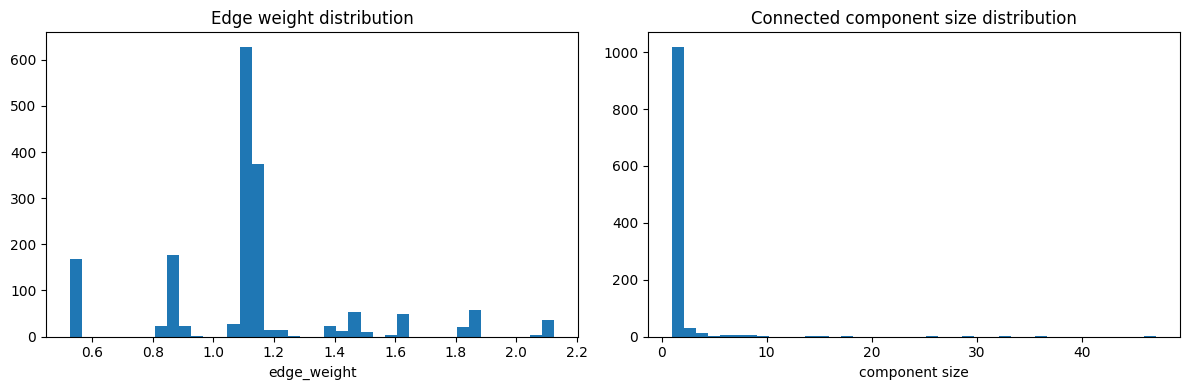

In [9]:
node_ids = shard_nodes_df["shard_id"].astype(str).tolist()
comp_sizes = s2.graph_component_sizes(node_ids, edges_df)

deg = Counter()
for _, r in edges_df.iterrows():
    a, b = str(r["shard_a"]), str(r["shard_b"])
    deg[a] += 1
    deg[b] += 1

isolated = sum(1 for s in node_ids if deg.get(s, 0) == 0)
possible_edges = len(node_ids) * (len(node_ids) - 1) / 2.0
sparsity = float(len(edges_df) / possible_edges) if possible_edges > 0 else np.nan

graph_diag_df = pd.DataFrame([
    {"metric": "n_nodes", "value": len(node_ids)},
    {"metric": "n_candidate_edges", "value": len(candidate_df)},
    {"metric": "n_weighted_edges", "value": len(edges_df)},
    {"metric": "graph_sparsity", "value": sparsity},
    {"metric": "n_isolated_shards", "value": isolated},
    {"metric": "largest_component_size", "value": comp_sizes[0] if comp_sizes else 0},
    {"metric": "n_components", "value": len(comp_sizes)},
])

display(graph_diag_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(edges_df["edge_weight"], bins=40)
axes[0].set_title("Edge weight distribution")
axes[0].set_xlabel("edge_weight")

axes[1].hist(comp_sizes, bins=min(40, max(5, len(comp_sizes))))
axes[1].set_title("Connected component size distribution")
axes[1].set_xlabel("component size")

plt.tight_layout()
plt.show()


## 5b) Shard graph visualization

Layout: **Kamada–Kawai** for small displays (≤350 nodes, ≤8000 edges); otherwise **spring** (`spring_layout`, Fruchterman–Reingold-style). **Node size ∝ √degree**; **edge width ∝ edge_weight**.

Large graphs are **downsampled** for speed (`VIZ_MAX_NODES` / `VIZ_MAX_EDGES`). By default only the **largest connected component** is drawn. Set **`VIZ_LCC_ONLY = False`** in the next cell to include **every** component (singletons and small islands together). With many components, a spring layout can look crowded — lower caps or run a second cell with `VIZ_LCC_ONLY = True` to focus on the giant component.


[viz] All 1088 connected components: 1673 nodes, 1720 edges.
[viz] Subsampled to top 1200 nodes by incident edge_weight sum.


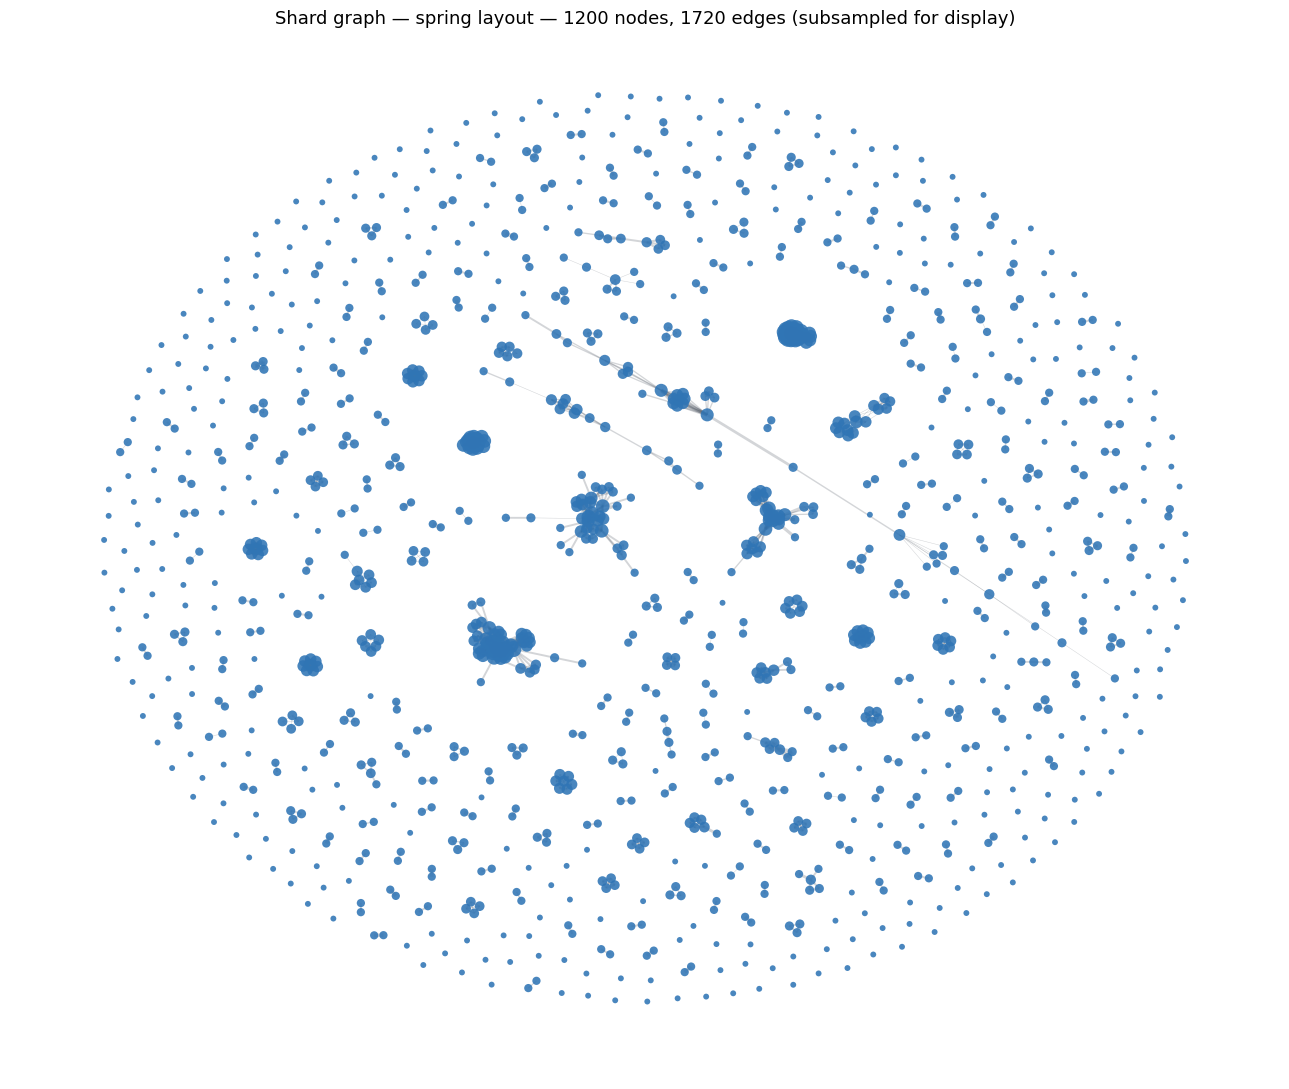

In [11]:
import networkx as nx

# --- Visualization caps (tune for speed vs detail) ---
VIZ_MAX_NODES = 1200
VIZ_MAX_EDGES = 6000
VIZ_SEED = 42
VIZ_ITER = 80

VIZ_LCC_ONLY = False  # False = draw all connected components (not only the largest)

if len(edges_df) == 0 or not node_ids:
    print("[viz] Skip: no weighted edges or empty node_ids.")
else:
    G = nx.Graph()
    G.add_nodes_from(str(x) for x in node_ids)
    for _, row in edges_df.iterrows():
        a, b = str(row["shard_a"]), str(row["shard_b"])
        w = float(row["edge_weight"])
        G.add_edge(a, b, weight=w)

    n_full, m_full = G.number_of_nodes(), G.number_of_edges()
    n_comp = nx.number_connected_components(G)
    if VIZ_LCC_ONLY and not nx.is_connected(G):
        lcc = max(nx.connected_components(G), key=len)
        G = G.subgraph(lcc).copy()
        print(
            f"[viz] Largest connected component only: {G.number_of_nodes()} nodes, "
            f"{G.number_of_edges()} edges "
            f"(full graph {n_full} nodes, {m_full} edges, {n_comp} components). "
            "Set VIZ_LCC_ONLY = False to include all components."
        )
    else:
        if not nx.is_connected(G):
            print(
                f"[viz] All {n_comp} connected components: {G.number_of_nodes()} nodes, "
                f"{G.number_of_edges()} edges."
            )
        else:
            print(f"[viz] Connected graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")

    n0, m0 = G.number_of_nodes(), G.number_of_edges()
    capped = False
    if n0 > VIZ_MAX_NODES:
        capped = True
        strength = {n: sum(G[n][nb].get("weight", 0.0) for nb in G[n]) for n in G.nodes()}
        keep = set(sorted(strength, key=strength.get, reverse=True)[:VIZ_MAX_NODES])
        G = G.subgraph(keep).copy()
        print(f"[viz] Subsampled to top {VIZ_MAX_NODES} nodes by incident edge_weight sum.")

    if G.number_of_edges() > VIZ_MAX_EDGES:
        capped = True
        ranked = sorted(
            ((u, v, float(G[u][v].get("weight", 0.0))) for u, v in G.edges()),
            key=lambda t: -t[2],
        )
        H = nx.Graph()
        H.add_nodes_from(G.nodes())
        for u, v, wt in ranked[:VIZ_MAX_EDGES]:
            H.add_edge(u, v, weight=wt)
        G = H
        print(f"[viz] Kept top {VIZ_MAX_EDGES} edges by edge_weight.")

    n, m = G.number_of_nodes(), G.number_of_edges()
    if n == 0:
        print("[viz] Skip: empty graph after filtering.")
    else:
        k_scale = 2.5 / max(np.sqrt(n), 1.0)
        layout_used = "spring"
        if n <= 350 and m <= 8000:
            try:
                pos = nx.kamada_kawai_layout(G, weight="weight")
                layout_used = "kamada_kawai"
            except Exception:
                pos = nx.spring_layout(
                    G,
                    weight="weight",
                    seed=VIZ_SEED,
                    iterations=VIZ_ITER,
                    k=k_scale,
                )
        else:
            pos = nx.spring_layout(
                G,
                weight="weight",
                seed=VIZ_SEED,
                iterations=VIZ_ITER,
                k=k_scale,
            )

        w_arr = np.array([G[u][v].get("weight", 0.0) for u, v in G.edges()], dtype=float)
        if w_arr.size and w_arr.max() > w_arr.min():
            w_norm = 0.35 + 2.8 * (w_arr - w_arr.min()) / (w_arr.max() - w_arr.min())
        else:
            w_norm = np.full_like(w_arr, 1.0, dtype=float) if w_arr.size else np.array([], dtype=float)

        deg = dict(G.degree())
        dmax = max(deg.values()) if deg else 1
        sizes = [18.0 + 120.0 * (deg[node] / dmax) ** 0.55 for node in G.nodes()]

        fig, ax = plt.subplots(figsize=(13, 11))
        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            width=w_norm,
            alpha=0.22,
            edge_color="#39424f",
        )
        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            node_size=sizes,
            node_color="#3075b5",
            alpha=0.88,
            linewidths=0,
        )
        title = f"Shard graph — {layout_used} layout — {n} nodes, {m} edges"
        if capped:
            title += " (subsampled for display)"
        ax.set_title(title, fontsize=13)
        ax.axis("off")
        fig.tight_layout()
        plt.show()


## 6) Can this shard graph expose bridges for fragmented campaigns?

This is a structural sanity check only (no final grouping):
- for campaigns spanning multiple shards, are shard pairs bridged in this graph?
- how often do we get any bridge vs full pairwise bridge coverage?


,metric,value
0,n_multi_shard_campaigns,32.000000
1,frac_campaigns_with_any_bridge,0.937500
2,frac_campaigns_all_pairs_bridged,0.312500
3,mean_frac_bridged_pairs,0.493125


Most weakly bridged campaigns:


,campaign_id,campaign_size,n_shards_touched,n_shard_pairs,n_bridged_pairs,frac_bridged_pairs,has_any_bridge,all_pairs_bridged
0,221,45,3,3,0,0.000000,False,False
1,51,31,2,1,0,0.000000,False,False
2,166,52,29,406,2,0.004926,True,False
3,15,21,14,91,1,0.010989,True,False
4,2,36,14,91,4,0.043956,True,False
5,46,26,13,78,7,0.089744,True,False
6,5,85,45,990,109,0.110101,True,False
7,178,69,10,45,6,0.133333,True,False
8,197,49,5,10,2,0.200000,True,False
9,3,31,13,78,17,0.217949,True,False


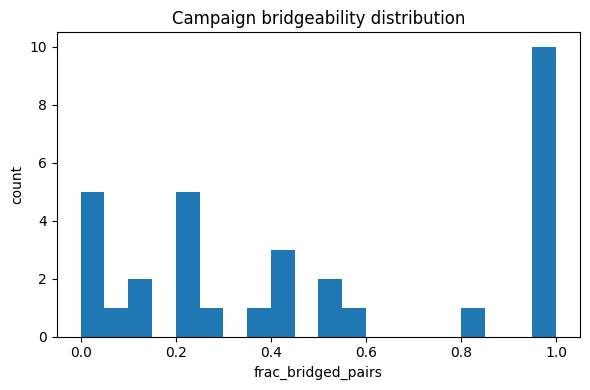

In [10]:
bridge_df = s2.campaign_bridgeability_from_shard_graph(
    assignments_df=assignments_used,
    gt_label_map=gt_label_map,
    edges_df=edges_df,
)

if bridge_df.empty:
    print("No multi-shard campaigns on GT-covered subset.")
else:
    bridge_summary_df = pd.DataFrame([
        {"metric": "n_multi_shard_campaigns", "value": int(len(bridge_df))},
        {"metric": "frac_campaigns_with_any_bridge", "value": float(bridge_df["has_any_bridge"].mean())},
        {"metric": "frac_campaigns_all_pairs_bridged", "value": float(bridge_df["all_pairs_bridged"].mean())},
        {"metric": "mean_frac_bridged_pairs", "value": float(bridge_df["frac_bridged_pairs"].mean())},
    ])
    display(bridge_summary_df)
    print("Most weakly bridged campaigns:")
    display(bridge_df.head(20))

    plt.figure(figsize=(6, 4))
    plt.hist(bridge_df["frac_bridged_pairs"], bins=20)
    plt.title("Campaign bridgeability distribution")
    plt.xlabel("frac_bridged_pairs")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


## 7) Save Step-2 graph artifacts

Saved outputs for Step 3 reuse:
- shard nodes table (features + members)
- shard centroid matrix
- candidate edge table
- weighted edge table (with evidence features)
- graph summary json


In [11]:
# Compact config summary for reproducibility / Step-3 experiments.
graph_config_summary = {
    "include_routing_channels_in_graph": bool(INCLUDE_ROUTING_CHANNELS_IN_GRAPH),
    "routing_infra_channels_logical": list(ROUTING_INFRA_CHANNELS_LOGICAL),
    "semantic_candidate": {
        "semantic_top_k": int(SEMANTIC_TOP_K),
        "semantic_min_cos": float(SEMANTIC_MIN_COS),
    },
    "edge_mix": {
        "semantic_weight": float(SEMANTIC_WEIGHT),
        "infra_weight": float(INFRA_WEIGHT),
        "temporal_weight": float(TEMPORAL_WEIGHT),
    },
    "candidate_infra_channels_logical": CANDIDATE_INFRA_CHANNELS_LOGICAL_FINAL,
    "scoring_infra_channels_logical": SCORING_INFRA_CHANNELS_LOGICAL,
    "enabled_infra_channels_logical": ENABLED_INFRA_CHANNELS_LOGICAL,
    "shard_edge_frequency_stat_note": s2.FREQUENCY_STAT_NOTE,
    "shard_edge_scoring_logical": SHARD_EDGE_SCORING_LOGICAL,
    "candidate_infra_channels_cols": CANDIDATE_INFRA_CHANNELS_COLS,
    "scoring_infra_channels_cols": SCORING_INFRA_CHANNELS_COLS,
    "shard_edge_scoring_cols": {c: channel_scoring_cols[c].to_jsonable() for c in sorted(channel_scoring_cols)},
    "channel_infra_weights_cols": channel_weights_cols,
}

print("[Step-2] Graph config summary:")
display(pd.json_normalize(graph_config_summary).to_dict(orient="records"))

saved = s2.save_step2_graph_artifacts(
    output_dir=STEP2_OUT_DIR,
    shard_nodes_df=shard_nodes_df,
    centroid_mat=shard_centroids,
    edges_df=edges_df,
    candidate_df=candidate_df,
    graph_config_summary=graph_config_summary,
)
for k, v in saved.items():
    print(f"{k}: {v}")


[Step-2] Graph config summary:


[{'include_routing_channels_in_graph': False,
  'routing_infra_channels_logical': ['origin_ip',
   'received_host',
   'return_path_email',
   'return_path_domain'],
  'candidate_infra_channels_logical': ['url',
   'sender_email_domain',
   'domain',
   'stem',
   'sender'],
  'scoring_infra_channels_logical': ['url',
   'sender_email_domain',
   'domain',
   'stem',
   'sender'],
  'enabled_infra_channels_logical': ['url',
   'sender_email_domain',
   'domain',
   'stem',
   'sender'],
  'shard_edge_frequency_stat_note': 'Shard-edge infra uses **shard document frequency**: for each artifact value, `shard_df` counts how many *shards* include that value in their union set (the same counting scheme as the existing IDF map: one increment per shard per distinct artifact). Email-level `email_df` counts how many *email rows* contain the value — diagnostic only. **URL / domain / stem** columns follow **email → url → {domain, stem}** only; popular/benign domains from `core/feature_set_extracti

nodes_csv: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_step2_graph\semantic_shard_step2_nodes.csv
centroids_npy: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_step2_graph\semantic_shard_step2_centroids.npy
edges_csv: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_step2_graph\semantic_shard_step2_edges_weighted.csv
candidates_csv: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_step2_graph\semantic_shard_step2_candidates.csv
graph_summary_json: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_step2_graph\semantic_shard_step2_graph_summary.json


## 8) Final summary (Step-2 viability)

This summary answers:
- graph scale/sparsity plausibility
- major evidence channels driving edge weights
- whether fragmented campaigns appear bridgeable
- readiness to proceed to Step 3 (community detection/grouping)


In [12]:
# Which scoring channels drive infra_score? (diagnostic: IDF-transform sums + mean capped contribution)
contrib_rows = []
for infra_col in SCORING_INFRA_CHANNELS_COLS:
    base = infra_col.replace("_set", "")
    idf_col = f"shared_{base}_idf_sum"
    ic = f"infra_contrib_{base}"
    ncut = f"shared_{base}_n_cutoff_filtered"
    row = {"channel": base}
    if idf_col in edges_df.columns:
        row["mean_shared_idf_sum"] = float(edges_df[idf_col].mean())
    if ic in edges_df.columns:
        row["mean_infra_contrib"] = float(edges_df[ic].mean())
    if ncut in edges_df.columns:
        # Avg artifacts dropped by max_shard_df on edges that had any raw overlap
        m = edges_df[f"shared_{base}_count"] > 0 if f"shared_{base}_count" in edges_df.columns else pd.Series(True, index=edges_df.index)
        row["mean_n_cutoff_filtered_if_overlap"] = float(edges_df.loc[m, ncut].mean()) if m.any() else float("nan")
    contrib_rows.append(row)
contrib_df = pd.DataFrame(contrib_rows)
if not contrib_df.empty and "mean_infra_contrib" in contrib_df.columns:
    contrib_df = contrib_df.sort_values("mean_infra_contrib", ascending=False)
elif not contrib_df.empty:
    contrib_df = contrib_df.sort_values("mean_shared_idf_sum", ascending=False)

print("Step-2 summary")
print(f"- shard nodes: {len(shard_nodes_df)}")
print(f"- candidate edges: {len(candidate_df)}")
print(f"- weighted edges: {len(edges_df)}")
print(f"- graph sparsity: {float(graph_diag_df.loc[graph_diag_df['metric']=='graph_sparsity','value'].iloc[0]):.6f}")
if 'bridge_summary_df' in globals() and not bridge_summary_df.empty:
    print(f"- multi-shard campaigns with any bridge: {float(bridge_summary_df.loc[bridge_summary_df['metric']=='frac_campaigns_with_any_bridge','value'].iloc[0]):.3f}")
    print(f"- mean bridged pair fraction: {float(bridge_summary_df.loc[bridge_summary_df['metric']=='mean_frac_bridged_pairs','value'].iloc[0]):.3f}")

print("\nPer-channel infra diagnostics (sort key: mean_infra_contrib when present):")
display(contrib_df)

if len(edges_df) > 0 and ('bridge_summary_df' in globals()) and (not bridge_summary_df.empty):
    any_bridge = float(bridge_summary_df.loc[bridge_summary_df['metric']=='frac_campaigns_with_any_bridge','value'].iloc[0])
    if any_bridge >= 0.6:
        print("\nInterpretation: shard graph looks plausible enough to proceed to Step 3 (community detection/grouping).")
    else:
        print("\nInterpretation: shard graph may be too sparse/weak for Step 3; tune candidate/weight rules first.")


Step-2 summary
- shard nodes: 1673
- candidate edges: 1720
- weighted edges: 1720
- graph sparsity: 0.001230
- multi-shard campaigns with any bridge: 0.938
- mean bridged pair fraction: 0.493

Per-channel infra diagnostics (sort key: mean_infra_contrib when present):


,channel,mean_shared_idf_sum,mean_infra_contrib,mean_n_cutoff_filtered_if_overlap
1,sender_email_domain,6.230461,0.715526,0.0
4,sender,4.515953,0.338166,0.0
0,url,1.777561,0.157814,0.0
2,domain,1.175275,0.104063,0.0
3,stem,0.838528,0.036716,0.0



Interpretation: shard graph looks plausible enough to proceed to Step 3 (community detection/grouping).
